In [1]:
import os
import json
import argparse
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.spatial.distance import cdist
except ImportError as e:
    raise ImportError("This script needs SciPy. Install with: pip install scipy") from e



In [3]:
# -------------------------
# Turtle path: sequence -> 2D polyline
# -------------------------
def turtle_path(delta_theta: np.ndarray, step_size: float = 1.0) -> np.ndarray:
    """
    delta_theta: (L,) turn increments in radians
    Returns: points (L+1, 2)
    """
    delta_theta = np.asarray(delta_theta).reshape(-1)
    theta = 0.0
    p = np.array([0.0, 0.0], dtype=float)
    pts = [p.copy()]
    for dth in delta_theta:
        theta += dth
        p = p + step_size * np.array([np.cos(theta), np.sin(theta)])
        pts.append(p.copy())
    return np.stack(pts, axis=0)


# -------------------------
# Target shape: circle point cloud
# -------------------------
def make_circle_target(n_points: int, radius: float) -> np.ndarray:
    t = np.linspace(0, 2 * np.pi, n_points, endpoint=False)
    return np.c_[radius * np.cos(t), radius * np.sin(t)]


# -------------------------
# Chamfer distance between two point sets
# -------------------------
def chamfer_distance(A: np.ndarray, B: np.ndarray) -> float:
    """
    A: (m,2), B: (n,2)
    """
    D = cdist(A, B)  # (m,n)
    return float(D.min(axis=1).mean() + D.min(axis=0).mean())


# -------------------------
# Oracle f(x): maximize (higher better)
# -------------------------
def oracle_f(
    delta_theta: np.ndarray,
    target_pts: np.ndarray,
    step_size: float,
    w_close: float = 0.2,
    w_smooth: float = 0.05,
) -> float:
    """
    f(x) = - chamfer(path, target) - w_close * closure - w_smooth * roughness

    We center the path before chamfer so translation doesn't matter.
    """
    pts = turtle_path(delta_theta, step_size=step_size)

    # center (translation invariance)
    pts0 = pts - pts.mean(axis=0, keepdims=True)
    shape_loss = chamfer_distance(pts0, target_pts)

    # closure: normalized to be O(1)
    closure = np.sum((pts[-1] - pts[0]) ** 2) / ((len(delta_theta) * step_size) ** 2)

    # smoothness / roughness: normalized to be O(1)
    if len(delta_theta) > 1:
        rough = np.mean(np.diff(delta_theta) ** 2) / (np.pi ** 2)
    else:
        rough = 0.0

    return -(shape_loss + w_close * closure + w_smooth * rough)


# -------------------------
# Helpers for generating sequences
# -------------------------
def moving_average_smooth(x: np.ndarray, win: int) -> np.ndarray:
    k = np.ones(win) / win
    return np.convolve(x, k, mode="same")


def generate_mixture_sequences(
    N: int,
    L: int,
    seed: int,
    circle_frac: float = 0.30,
    spiral_frac: float = 0.20,
    random_frac: float = 0.30,
    zigzag_frac: float = 0.20,
    smooth_win: int = 9,
    noise_sigma: float = 0.10,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      X: (N, L) sequences in radians, clipped to [-pi, pi]
      types: (N,) int labels:
         0=circle-ish, 1=spiral-ish, 2=random-smooth, 3=zigzag
    """
    rng = np.random.default_rng(seed)

    n0 = int(N * circle_frac)
    n1 = int(N * spiral_frac)
    n2 = int(N * random_frac)
    n3 = N - n0 - n1 - n2
    assert n3 >= 0

    X = np.zeros((N, L), dtype=np.float32)
    types = np.zeros((N,), dtype=np.int64)

    # Circle-ish: Δθ ≈ ± 2π/L + small smooth noise
    base_circle = (2 * np.pi / L)
    for i in range(n0):
        sign = rng.choice([-1.0, 1.0])
        raw = sign * base_circle + noise_sigma * rng.standard_normal(L)
        X[i] = moving_average_smooth(raw, smooth_win)
        types[i] = 0

    # Spiral-ish: Δθ ramps slightly over time
    for i in range(n1):
        sign = rng.choice([-1.0, 1.0])
        base = sign * base_circle
        ramp = rng.uniform(-0.12, 0.12) * np.linspace(-1, 1, L)  # small change
        raw = base + ramp + noise_sigma * rng.standard_normal(L)
        X[n0 + i] = moving_average_smooth(raw, smooth_win)
        types[n0 + i] = 1

    # Random smooth curves around 0
    for i in range(n2):
        raw = 0.35 * rng.standard_normal(L)
        X[n0 + n1 + i] = moving_average_smooth(raw, smooth_win)
        types[n0 + n1 + i] = 2

    # Zigzag: alternating turns (creates sharp-ish polyline shapes)
    for i in range(n3):
        amp = rng.uniform(0.20, 0.60)
        raw = amp * ((-1.0) ** np.arange(L)) + noise_sigma * rng.standard_normal(L)
        X[n0 + n1 + n2 + i] = moving_average_smooth(raw, max(3, smooth_win // 3))
        types[n0 + n1 + n2 + i] = 3

    # clip to valid range
    X = np.clip(X, -np.pi, np.pi).astype(np.float32)

    # shuffle
    idx = rng.permutation(N)
    return X[idx], types[idx]


# -------------------------
# Visualization
# -------------------------
def plot_paths_grid(X, y, types, step_size, outpath, title, n=12):
    rng = np.random.default_rng(0)
    idx = rng.choice(len(X), size=n, replace=False)

    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, i in zip(axes, idx):
        pts = turtle_path(X[i], step_size=step_size)
        ax.plot(pts[:, 0], pts[:, 1], linewidth=2)
        ax.scatter([pts[0, 0]], [pts[0, 1]], s=30)

        ax.set_aspect("equal", "box")
        ax.axis("off")
        ax.set_title(f"type={types[i]}  f={y[i]:.3f}")

    for ax in axes[len(idx):]:
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=160)
    plt.close(fig)


def plot_hist_by_type(y, types, outpath, title):
    fig, ax = plt.subplots(figsize=(8, 4))
    for t in np.unique(types):
        ax.hist(y[types == t], bins=40, alpha=0.6, label=f"type {t}", density=True)
    ax.set_title(title)
    ax.set_xlabel("oracle f(x)")
    ax.set_ylabel("density")
    ax.legend()
    plt.tight_layout()
    plt.savefig(outpath, dpi=160)
    plt.close(fig)


def plot_sequence_pca(X, y, outpath, title):
    """
    PCA via SVD (no sklearn).
    """
    X0 = X - X.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X0, full_matrices=False)
    Z = U[:, :2] * S[:2]  # (N,2)

    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=y, s=10)
    plt.colorbar(sc, ax=ax, label="oracle f(x)")
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    plt.tight_layout()
    plt.savefig(outpath, dpi=160)
    plt.close(fig)



In [5]:
N = 8000
L = 40
seed = 123
step_size = 1
target_points = 320

6.372747421591187


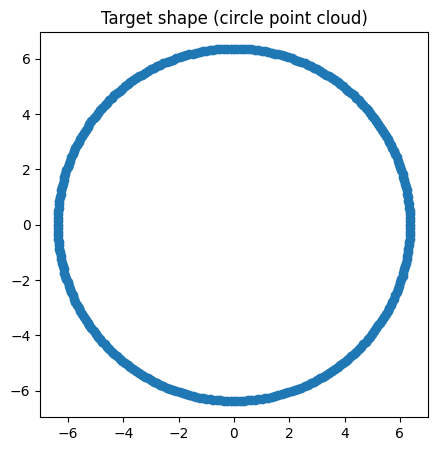

In [ ]:
R_poly = step_size / (2 * np.sin(np.pi / L))
target = make_circle_target(target_points, radius=R_poly)
# print how does it look the raw target - just the first one
print(R_poly)
#print(target)

plt.figure(figsize=(5, 5))
plt.plot(target[:, 0], target[:, 1], 'o')
plt.title("Target shape (circle point cloud)")
plt.axis("equal")
plt.show()


In [10]:
# Generate dataset
X, types = generate_mixture_sequences(
    N=N,
    L=L,
    seed=seed,
    smooth_win=9,
    noise_sigma=0.10,
)

# Compute oracle scores
y = np.array([oracle_f(x, target, step_size=step_size) for x in X], dtype=np.float32)

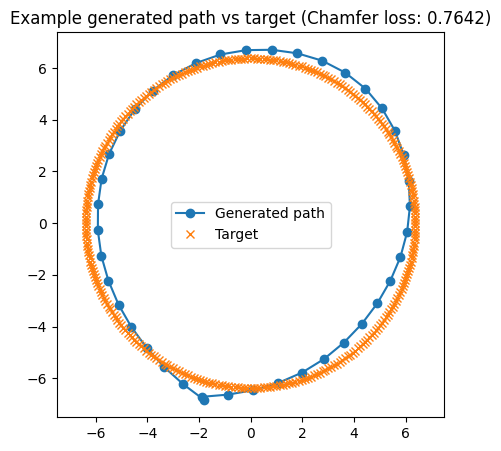

Shape loss: 0.7641592505231671
Closure: 1.112689251041587e-05
Roughness: 2.3321378e-05
Oracle f(x): -0.7641626419706243


In [34]:
#dimension of the target [320, 2]
delta_theta = X[0]
pts = turtle_path(delta_theta, step_size=step_size)
pts0 = pts - pts.mean(axis=0, keepdims=True)

shape_loss = chamfer_distance(pts0, target)

#plot pls

plt.figure(figsize=(5, 5))
plt.plot(pts0[:, 0], pts0[:, 1], '-o', label="Generated path")
plt.plot(target[:, 0], target[:, 1], 'x', label="Target")
plt.title(f"Example generated path vs target (Chamfer loss: {shape_loss:.4f})")
plt.axis("equal")
plt.legend()
plt.show()

closure = np.sum((pts[-1] - pts[0]) ** 2) / ((len(delta_theta) * step_size) ** 2)


if len(delta_theta) > 1:
    rough = np.mean(np.diff(delta_theta) ** 2) / (np.pi ** 2)

print("Shape loss:", shape_loss)
print("Closure:", closure)
print("Roughness:", rough)

oracle_f_value = -(shape_loss + 0.2 * closure + 0.05 * rough)

print("Oracle f(x):", oracle_f_value)


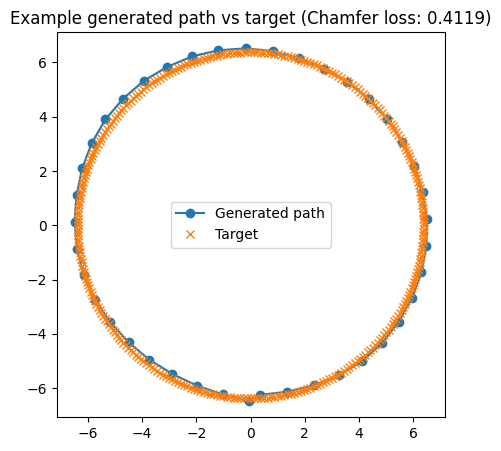

Shape loss: 0.4118528797022103
Closure: 0.00014019239994063698
Roughness: 4.0406045e-05
Oracle f(x): -0.41188293848438884


In [36]:
# get minimum and maximum of y and visualize them
y_max = np.max(y)
x_max = X[np.argmax(y)]

delta_theta = x_max
pts = turtle_path(delta_theta, step_size=step_size)
pts0 = pts - pts.mean(axis=0, keepdims=True)

shape_loss = chamfer_distance(pts0, target)

#plot pls

plt.figure(figsize=(5, 5))
plt.plot(pts0[:, 0], pts0[:, 1], '-o', label="Generated path")
plt.plot(target[:, 0], target[:, 1], 'x', label="Target")
plt.title(f"Example generated path vs target (Chamfer loss: {shape_loss:.4f})")
plt.axis("equal")
plt.legend()
plt.show()

closure = np.sum((pts[-1] - pts[0]) ** 2) / ((len(delta_theta) * step_size) ** 2)


if len(delta_theta) > 1:
    rough = np.mean(np.diff(delta_theta) ** 2) / (np.pi ** 2)

print("Shape loss:", shape_loss)
print("Closure:", closure)
print("Roughness:", rough)

oracle_f_value = -(shape_loss + 0.2 * closure + 0.05 * rough)

print("Oracle f(x):", oracle_f_value)

